# Tutorial: **δHBV 1.1p**

---

This notebook demonstrates training and forward simulation with the δHBV 1.1p model developed by [Yalan Song et al. (2025)](https://doi.org/10.22541/essoar.172304428.82707157/v2). A pre-trained model is provided for those who only wish to run the model forward.

For explanation of model structure, methodologies, data, and performance metrics, please refer to Song's publication [below](#publication). If you find this code is useful in your own work, please include the aforementioned citation.

**Note**: If you are new to the dMG framework, we suggest first looking at our [δHBV 1.0 tutorial](./../hydrology/example_dhbv.ipynb).

<br>

### Before Running:
- **Environment**: See [setup.md](./../../docs/setup.md) for ENV setup. dMG must be installed with dependencies + hydrodl2 to run this notebook.

- **Model**: Download pretrained δHBV 1.1p model weights from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/models/dhbv_1_1p_trained.zip). Then update the model config:

    - In [`./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml`](./../conf/config_dhbv_1_1p.yaml), update *trained_model* with your path to the parent directory containing both trained model weights `dhbv_1_1p_ep50.pt` (or *Ep100*) **and** normalization file `normalization_statistics.json`.
    - **Note**: make sure this path includes the last closing forward slash: e.g., `./your/path/to/model/`.

- **Data**: Download the CAMELS data extraction from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/camels/camels_data.zip). Then, updated the data configs:

    - In [`./generic_deltamodel/example/conf/observations/camels_531.yaml`](./../conf/observations/camels_531.yaml) and [`camels_671.yaml`](./../conf/observations/camels_671.yaml), update...
        1. *data_path* with `camels_dataset` path,
        2. *gage_info* with `gage_ids.npy` path,
        3. *subset_path* with `531_subset.txt` path (camels_531 only).

    - The full 671-basin or 531-basin CAMELS datasets can be selected by setting `observations: camels_671` or `camels_531` in the model config, respectively.

- **Hardware**: The NNs used in this model require CUDA support only available with Nvidia GPUs. For those without access, T4 GPUs can be used when running this notebook with dMG on [Google Colab](https://colab.research.google.com/).

<br>

### Publication:

*Yalan Song, Kamlesh Sawadekar, Jonathan M Frame, Ming Pan, Martyn Clark, Wouter J M Knoben, Andrew W Wood, Trupesh Patel, Chaopeng Shen. "Physics-informed, Differentiable Hydrologic  Models for Capturing Unseen Extreme Events." ESS Open Archive (2025). https://doi.org/10.22541/essoar.172304428.82707157/v2.*

<br>

### Issues:
For questions, concerns, bugs, etc., please reach out by posting an [issue](https://github.com/mhpi/generic_deltamodel/issues).

---


## 1. Forward δHBV 1.1p Simulation Mode (no output metrics saved)

After completing training or you have pretrianed models saved, forward δHBV 1.1p with the code block below.

Note:
- The settings defined in the config `./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml` are set to replicate benchmark performance on 531 CAMELS basins.
- The first year (`warm_up` in the config, default is 365 days) of the inference period is used for initializing HBV's internal states (water storages) and is, therefore, excluded from the model's prediction output.

### 1.1 Simulation Settings Demonstration

In [1]:
import sys
sys.path.append('../../') 
from src.dmg import ModelHandler 
from src.dmg.core.utils import import_data_loader, print_config, print_dataset_info, set_randomseed
from example import load_config 
#------------------------------------------#
# Define model settings here.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
#------------------------------------------#

# 1. Load configuration dictionary of model parameters and options.
config = load_config(CONFIG_PATH)
config['mode'] = 'simulation'

print_config(config)
# print("Config Keys:", config.keys())
# print("config['multimodel_type']", config['multimodel_type'])
# Set random seed for reproducibility.
set_randomseed(config['random_seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True) # model key is ['Hbv_1_1p'] 
nn_model = model.model_dict["Hbv_1_1p"].nn_model

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=False, overwrite=False)
print_dataset_info(data_loader.dataset)   


Current Configuration
  Experiment Mode:    simulation          
  Model 1:            Hbv_1_1p            

Data Loader
  Data Source:        camels_531          
  Simulation Range :  2009/10/01          2012/09/30          

Model Parameters
  Train Epochs:       100                 Batch Size:         100                 
  Dropout:            0.5                 Hidden Size:        256                 
  Warmup:             365                 Concurrent Models:  16                  
  Loss Fn:            NseBatchLoss        

Machine
  Use Device:         cuda:0              


Dataset Inputs
Dataset key    Shape               Description
------------------------------------------------------------
x_phy          (1096, 531, 3)       # [time, basin, forcing_features]
c_phy          (531, 0)             # [basin, attr_features] (no physical attributes here)
x_nn           (1096, 531, 3)       # [time, basin, nn_forcing_features]
c_nn           (531, 35)            # [basin, nn_at

### 1.2 Simulation with Daymet Forcings Only

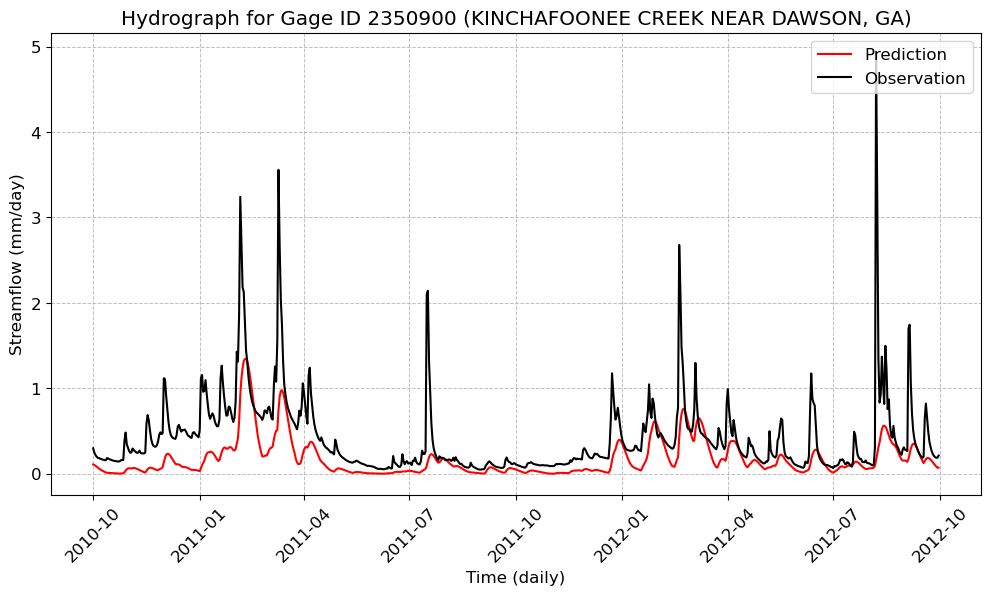

In [2]:
import json
import numpy as np
import pandas as pd
import torch
from tempfunctions import *
from src.dmg.core.post import plot_hydrograph
from src.dmg.core.utils import Dates

output = model(
    data_loader.dataset,
    eval=True,
)

# # Gage settings
gage_ids = np.load(config["observations"]["gage_info"], allow_pickle=True)
subset_file = config["observations"]["subset_path"]
GAGE_NAME_PATH = "./predownloaded/camels_name.txt"

with open(subset_file, "r") as f:
    content = f.read().strip()
gage_ids_subset = json.loads(content) if content.startswith("[") else np.loadtxt(subset_file, dtype=int).tolist()  

# 1. Predictions and timesteps
GAGE_ID = 2350900
pred = output['Hbv_1_1p']['streamflow']
timesteps = Dates(config['simulation'], config['delta_model']['rho']).batch_daily_time_range
warm_up = config['delta_model']['phy_model']['warm_up']
timesteps = timesteps[warm_up:]

if config['observations']['name'] == 'camels_671':
    basin_idx = list(gage_ids).index(GAGE_ID) if GAGE_ID in gage_ids else None
    basin_pool = list(gage_ids)
elif config['observations']['name'] == 'camels_531':
    basin_idx = list(gage_ids_subset).index(GAGE_ID) if GAGE_ID in gage_ids_subset else None
    basin_pool = list(gage_ids_subset)

# prediction can be numpy
streamflow_pred_basin = pred[:, basin_idx].squeeze()
if torch.is_tensor(streamflow_pred_basin):
    streamflow_pred_basin = streamflow_pred_basin.detach().cpu().numpy()

# keep obs as torch tensor so plot_hydrograph does not zero it out
dataset = data_loader.dataset
obs_basin = dataset["target"][:, basin_idx].squeeze()
if not torch.is_tensor(obs_basin):
    obs_basin = torch.as_tensor(obs_basin)

# 2. Plot
RESAMPLE = 'D'
obs_basin = obs_basin[warm_up:]
gage_name = obtain_gage_name(GAGE_NAME_PATH, GAGE_ID)

plot_hydrograph(
    timesteps,
    streamflow_pred_basin,
    obs=obs_basin,
    resample=RESAMPLE,
    title=f"Hydrograph for Gage ID {GAGE_ID} ({gage_name})",
    ylabel='Streamflow (mm/day)',
)

### 1.3 GEFS Simulation with warm start

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import random
from src.dmg.core.utils import Dates 
from hydrodl2.models.hbv import HBV1_1p as h1pp

# ---------------- Simulation settings ---------------- #
ENSEMBLE_START_DATE     = pd.to_datetime("2012-09-16")
FORECAST       = 15
N_ENSEMBLES    = 5
N_BASINS       = 5   # randomly pick basins
SEED           = 1234  # config["random_seed"]
RANDOM         = False
device         = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
GEFS_DIR       = "/u/st/dr/awwood/aw-ciroh-proj/projects/dl_da/daymet-gefs-camels-gII"
WINDOW         = 30 # pre-processing on correcting window (in days)
CORRECTION     = 'scalar'  #  # or 'cdf'
POST           = True

# HBV options
staind   = -1
tdRep    = [1, 3, 13]
VAR_F    = config['delta_model']['phy_model']['forcings']
BUFFTIME = config['delta_model']['phy_model']['warm_up']
routing  = config['delta_model']['phy_model']['routing']  
dydrop   = config['delta_model']['phy_model']['dy_drop']  
nmul     = config["delta_model"]["phy_model"]["nmul"]

# ---------------- Select 5 random basins ---------------- #
selected_basins = [9035900, 2350900] # selected_basins = selectbasins(RANDOM, SEED)
sidx, eidx, timesteps, history_len = startid_endid(config, ENSEMBLE_START_DATE, FORECAST)
hbv = h1pp.HBV().to(device) 

# ---------------- Loop over selected basins ---------------- #
for GAGE_ID in selected_basins:
    print(f"\n=== Running forecast for basin {GAGE_ID} ===")
    basin_idx = basin_pool.index(GAGE_ID) 
    
    # ---------------- Get inputs of all forcings 38 from trained NN ---------------- #
    hist_dict = {
        "xc_nn_norm":dataset["xc_nn_norm"][:sidx, basin_idx:basin_idx+1, :].clone()   
    } # [715, 1, 38] 2years - 15 days = 715 days
    print(f"hist_dict['xc_nn_norm'] shape: {hist_dict['xc_nn_norm'].shape}")
    
    # ---------------- Get parameters from trained NN ---------------- #
    pars_hist, rtwts_hist = get_parameters_from_model(model.model_dict["Hbv_1_1p"], hist_dict, n_par=14, mu=nmul, device=device) # pars: 715, 1, 14, 16    rts: 1, 2
    
    pars_first = pars_hist[:1].repeat(sidx, 1, 1, 1) 
    pars_last = pars_hist[-1:].repeat(FORECAST, 1, 1, 1) 
    
    # --- Warm-up HBV with RAW forcings (Daymet) ---
    with torch.no_grad():
        forc_hist = torch.nan_to_num(dataset["x_phy"][:sidx, basin_idx:basin_idx+1, :3], nan=0.0)
        Qs_hist, sp, mw, sm, suz, slz = hbv(
            x=forc_hist, parameters=pars_first,
            staind=staind, tdlst=tdRep,
            mu=nmul, muwts=None, rtwts=rtwts_hist, bufftime=BUFFTIME,
            outstate=True, instate=False,
            routOpt=routing, dydrop=dydrop,
        )
    warm_states = (sp, mw, sm, suz, slz) # 
    checknans(warm_states)
    
    ###add retest###
    # warm_init = tuple(s[-1].detach() for s in warm_states)
    warm_init = tuple(s.detach() for s in warm_states)
    with torch.no_grad():
        forc_fut = torch.nan_to_num(
        dataset["x_phy"][sidx:sidx + FORECAST, basin_idx:basin_idx+1, :3], nan=0.0
    )
        rtwts_fut = rtwts_hist 
        Qf, sp_f, mw_f, sm_f, suz_f, slz_f = hbv(
            x=forc_fut,
            parameters=pars_last,
            staind=staind, tdlst=tdRep,
            mu=nmul, muwts=None, rtwts=rtwts_fut, bufftime=BUFFTIME,
            outstate=True,
            instate=True,
            init_states=warm_init,   
            routOpt=routing, dydrop=dydrop,
    )
    # retest deterministic forecast (HBV forward run)
    Qf_det = Qf[:, 0, 0].detach().cpu().numpy()   # shape [forecast_len]
    
    ###single continuos run
    T_total = sidx + FORECAST

    with torch.no_grad():
        forc_all = torch.nan_to_num(
            dataset["x_phy"][:T_total, basin_idx:basin_idx+1, :3],
            nan=0.0
        )

        pars_all = torch.cat([pars_first, pars_last], dim=0)  # [sidx+FORECAST, 1, 14, 16]
        # If you want to be extra safe:
        assert forc_all.shape[0] == pars_all.shape[0], (forc_all.shape, pars_all.shape)

        Q_all, sp_all, mw_all, sm_all, suz_all, slz_all = hbv(
            x=forc_all,
            parameters=pars_all,
            staind=staind, tdlst=tdRep,
            mu=nmul, muwts=None,
            rtwts=rtwts_hist,         # NOTE: no slicing
            bufftime=BUFFTIME,
            outstate=True, instate=False,
            routOpt=routing, dydrop=dydrop,
        )
    Q_all_np = Q_all[:, 0, 0].detach().cpu().numpy()   # length sidx+FORECAST
       

    print("sidx:", sidx, "FORECAST:", FORECAST)
    print("len(Q_all_np):", len(Q_all_np))
    print("expected T_total:", sidx + FORECAST)

    Qf_cont  = Q_all_np[sidx:sidx + FORECAST]          # length FORECAST


    # ---------------- Run ensembles ---------------- #
    ens_preds = run_warm_forecasts(hbv, pars_last, rtwts_hist, warm_states, GAGE_ID, ENSEMBLE_START_DATE, FORECAST, VAR_F, N_ENSEMBLES, GEFS_DIR, timesteps, WINDOW, CORRECTION, staind, tdRep, nmul, routing, dydrop, device) 
    
    
    # ---------------- Plotting ---------------- #
    obs_full_window = (
        dataset["target"][sidx - history_len : eidx, basin_idx, 0]
        .detach().cpu().numpy()
    )

    Qs_full = Qs_hist[:, 0, 0].detach().cpu().numpy()
    sim_pre_GEFS = Qs_full[-(history_len+1):]
    if POST:
        ens_preds = post_processing(sim_pre_GEFS, ens_preds) # post-processing
    
    save_path = os.path.join("figs", f"GEFS_{GAGE_ID}", f"GEFS_{GAGE_ID}_{CORRECTION}_w{WINDOW}_p{POST}.png")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    print("all related length", len(obs_full_window), len(sim_pre_GEFS), len(ens_preds), history_len, len(Q_all_np), sidx)

    save_dir = os.path.join("figs", f"GEFS_{GAGE_ID}")
    plot_forecast_separate(
        GAGE_NAME_PATH=GAGE_NAME_PATH,
        gage_id=GAGE_ID,
        start_date=ENSEMBLE_START_DATE,
        obs=obs_full_window,
        sim=sim_pre_GEFS,
        ens_preds=ens_preds,
        history_len=history_len,
        Q_all_np=Q_all_np,
        sidx=sidx,
        FORECAST=FORECAST,
        BUFFTIME=BUFFTIME,
        det_pred=Qf_det,
        save_dir=save_dir,
        file_prefix=f"GEFS_{GAGE_ID}_{CORRECTION}_w{WINDOW}_p{POST}",
    )
    
    print(f"Saved plot for basin {GAGE_ID} → {save_path}")

check on config {'start_time': '2009/10/01', 'end_time': '2012/09/30', 'batch_size': 25}
sidx, eidx, timesteps, history_len are 1081 1096 DatetimeIndex(['2009-10-01', '2009-10-02', '2009-10-03', '2009-10-04',
               '2009-10-05', '2009-10-06', '2009-10-07', '2009-10-08',
               '2009-10-09', '2009-10-10',
               ...
               '2012-09-21', '2012-09-22', '2012-09-23', '2012-09-24',
               '2012-09-25', '2012-09-26', '2012-09-27', '2012-09-28',
               '2012-09-29', '2012-09-30'],
              dtype='datetime64[ns]', length=1096, freq='D') 716

=== Running forecast for basin 9035900 ===
hist_dict['xc_nn_norm'] shape: torch.Size([1081, 1, 38])
here t is where it goes!
outside goes here?
qsim should have a value???


ValueError: routOpt=True requires routing parameters.